<a href="https://colab.research.google.com/github/yooongZa/AIFFEL_Quest_EPA/blob/main/0930_private_rag_bikeseoul_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 로컬 RAG 만들고 개선하기

- **트랙 1 — 인덱싱 처리량과 배치 최적화:** 제한된 GPU 메모리에서 배치 크기와 정밀도를 조절해 처리 속도를 높이고 싶었다.
- **트랙 2 — 하이브리드 검색:** 의미가 비슷한 질문과 ‘365일권’ 같은 정확한 식별자가 포함된 질문을 함께 처리하고 싶었다.
- **트랙 4 — 부모–자식 청킹:** 작은 문장으로 검색하면서 답변에는 관련 조건과 예외까지 전달하는 효과를 확인하고 싶었다.


- 기준선: 구조 기반 청킹 → BGE-M3 → Qdrant → Qwen.



## Step 0. 환경 준비


In [1]:
%pip install -q "langchain-huggingface==0.3.*" "langchain-text-splitters==0.3.*" "sentence-transformers==5.7.*" "qdrant-client==1.12.*" "transformers==4.57.*" "accelerate==1.14.*" "bitsandbytes==0.50.*" "rank_bm25==0.2.2" pandas matplotlib tabulate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.2/267.2 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 113.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 83.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 115.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 42.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 461.3/461.3 kB 36.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 106.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.2/343.2 kB 30.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is t

In [2]:
import os
import torch
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

# 전체 재실행 전에 이전 오프라인 설정을 해제한다.
os.environ.pop("HF_HUB_OFFLINE", None)
os.environ.pop("TRANSFORMERS_OFFLINE", None)

if not torch.cuda.is_available():
    raise RuntimeError("Colab에서 GPU 런타임을 선택한 뒤 다시 실행하세요.")

print(f"GPU : {torch.cuda.get_device_name(0)}")
print(f"VRAM : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
os.makedirs("bikeseoul_rag_results", exist_ok=True)

GPU : Tesla T4
VRAM : 15.6 GB


## Step 1. 문서 준비
출처: [서울시설공단 공공자전거 안내](https://sisul.or.kr/open_content/traffic/bikeseoul.jsp), 확인일 2026-09-30.
이용방법·요금표·안전수칙의 사실을 한국어로 정리했다. 표는 문장으로 바꾸고 중복·홍보 문구와 통계는 제외했다.
세부 제목은 실습용이며 공식 조항 번호가 아니다. 원문에 없는 요금이나 규정은 추가하지 않았다.
아래 셀은 예제의 `%%writefile` 방식으로 문서를 만든다.

In [3]:
%%writefile bikeseoul_guide.md
# 따릉이 이용 안내

## 이용방법

### 앱 설치와 이용권 구매

앱스토어에서 따릉이 앱을 설치한다.

이용권을 구매한 뒤 이용한다.

### QR 또는 자전거번호로 대여

따릉이 앱에서 자전거의 QR코드를 스캔해 대여한다.

자전거번호를 입력하는 방법도 있다.

### 반납 절차와 완료 확인

대여소 거치대에 자전거를 놓고 잠금장치를 당겨 잠근다.

스마트폰에 반납메시지가 도착했는지 확인한 뒤 이동한다.

## 이용권안내

### 일일권 요금

일일권의 1시간 단위 반복 이용권: 1,000원.

일일권의 2시간 단위 반복 이용권: 2,000원.

일일권의 3시간 단위 반복 이용권: 3,000원.

### 7일권 요금

7일권의 1시간 단위 반복 이용권: 3,000원.

7일권의 2시간 단위 반복 이용권: 4,000원.

7일권의 3시간 단위 반복 이용권은 표에 '-'로 표시되어 있다.

### 30일권 요금

30일권의 1시간 단위 반복 이용권: 5,000원.

30일권의 2시간 단위 반복 이용권: 7,000원.

30일권의 3시간 단위 반복 이용권은 표에 '-'로 표시되어 있다.

### 180일권 요금

180일권의 1시간 단위 반복 이용권: 15,000원.

180일권의 2시간 단위 반복 이용권: 20,000원.

180일권의 3시간 단위 반복 이용권은 표에 '-'로 표시되어 있다.

### 365일권 요금

365일권의 1시간 단위 반복 이용권: 30,000원.

365일권의 2시간 단위 반복 이용권: 40,000원.

365일권의 3시간 단위 반복 이용권은 표에 '-'로 표시되어 있다.

### 반납 후 재대여 조건

선택한 1시간·2시간·3시간 대여시간 안에 정상 반납해야 한다.

이 조건을 지키면 이용권 기간 동안 횟수 제한 없이 다시 대여할 수 있다.

### 대여시간 초과 요금

선택한 1시간·2시간·3시간 안에 반납하지 않으면 기본시간 초과에 해당한다.

초과 요금은 5분당 200원이다.

### 비회원 이용권

비회원이 구매할 수 있는 이용권은 일일권으로 한정된다.

## 자전거 안전운행안내

### 이용 가능한 나이

이용 대상은 만 13세 이상이다.

### 주행 중 전자기기

주행 중에는 휴대전화와 DMB를 사용하면 안 된다.

주행하면서 이어폰을 착용하는 것도 금지된다.

### 우산과 손에 든 물건

자전거를 타면서 우산을 쓰거나 손에 물건을 들지 않는다.

### 자전거도로와 우측통행

자전거도로를 이용한다.

다른 도로에서는 오른쪽 가장자리로 통행한다.

### 주행 전 ABC 점검

탑승 전에 ABC를 확인해 자전거 결함으로 인한 사고를 예방한다.

ABC의 항목은 Air, Brake, Chain이다.

### 안전거리와 주행 대열

자전거 사이의 거리를 확보하고 한 줄로 주행한다.

급하게 방향을 바꾸지 말고 주변 차량과 사람을 살핀다.

### 보호장구와 복장

안전모·보호대 같은 보호장구를 착용한다.

미끄럽지 않은 신발과 편안한 옷을 착용한다.

### 횡단보도와 자전거횡단도

횡단보도에서는 내려서 자전거를 끌고 간다.

자전거횡단도가 있으면 그곳에서는 자전거를 타고 건널 수 있다.

### 교통법규 준수

안내문은 자전거도 법상 차에 해당한다고 설명하며 교통법규 준수를 요구한다.

### 주행 금지 구역

자동차전용도로와 자전거 탑승금지구역에서는 주행할 수 없다.

### 음주 후 운전

안내문은 음주 후 자전거 운행에 벌금이 부과된다고 설명한다.

Writing bikeseoul_guide.md


In [4]:
with open("bikeseoul_guide.md", encoding="utf-8") as f:
    document = f.read()

print(f"문서 길이 : {len(document)}자")

문서 길이 : 1706자


## Step 2. 구조 기반 청킹과 평가 질문
예제의 `MarkdownHeaderTextSplitter`를 사용한다. `##`는 분류, `###`는 이용권·절차·수칙별 항목이다.
부모는 각 항목 전체로 만들어 요금과 시간의 관계, 조건과 예외를 함께 보존한다.
큰 청크 3개만 만들면 Hit@3가 의미 없어지므로 항목별로 나눈다.

평가 세트는 예제와 같은 `(질문, 정답 청크 번호)` 형식이다. 질문과 정답은 실행 전에 고정한다.
이 질문 세트는 설정 비교용이며 별도 시험 세트에서 검증한 일반화 성능은 아니다.

In [5]:
from langchain_text_splitters import MarkdownHeaderTextSplitter

headers_to_split_on = [
    ("#", "문서"),
    ("##", "분류"),
    ("###", "항목"),
]

md_splitter = MarkdownHeaderTextSplitter(headers_to_split_on=headers_to_split_on)
md_chunks = md_splitter.split_text(document)

print(f"청크 수 : {len(md_chunks)}")

# 청크 목록을 번호와 함께 확인합니다
chunks = md_chunks

for i, c in enumerate(chunks):
    print(f"[{i}] {c.metadata.get('항목', c.metadata.get('분류', ''))}")

청크 수 : 22
[0] 앱 설치와 이용권 구매
[1] QR 또는 자전거번호로 대여
[2] 반납 절차와 완료 확인
[3] 일일권 요금
[4] 7일권 요금
[5] 30일권 요금
[6] 180일권 요금
[7] 365일권 요금
[8] 반납 후 재대여 조건
[9] 대여시간 초과 요금
[10] 비회원 이용권
[11] 이용 가능한 나이
[12] 주행 중 전자기기
[13] 우산과 손에 든 물건
[14] 자전거도로와 우측통행
[15] 주행 전 ABC 점검
[16] 안전거리와 주행 대열
[17] 보호장구와 복장
[18] 횡단보도와 자전거횡단도
[19] 교통법규 준수
[20] 주행 금지 구역
[21] 음주 후 운전


In [6]:
# 의미 질문 10개
eval_set = [
    ('가입하지 않고도 이용권을 살 수 있어? 어떤 종류를 살 수 있어?', 10),  # 비회원 이용권
    ('반납한 뒤 또 빌리고 싶은데 횟수 제한이 있어?', 8),  # 반납 후 재대여 조건
    ('빌린 자전거를 제시간에 돌려주지 못하면 추가로 얼마를 내야 해?', 9),  # 대여시간 초과 요금
    ('자전거를 세워 놓고 잠갔어. 바로 떠나도 될까?', 2),  # 반납 절차와 완료 확인
    ('횡단보도를 건널 때 자전거를 계속 타도 돼? 따로 자전거가 건너는 곳이 있으면?', 18),  # 횡단보도와 자전거횡단도
    ('초등학생 동생과 타려는데 이용 가능한 최소 나이는 몇 살이야?', 11),  # 이용 가능한 나이
    ('자전거 전용 길이 없는 도로에서는 어디로 가야 해?', 14),  # 자전거도로와 우측통행
    ('음악을 들으려고 이어폰을 끼고 달려도 돼?', 12),  # 주행 중 전자기기
    ('비가 오면 한 손으로 우산을 잡고 타도 괜찮아?', 13),  # 우산과 손에 든 물건
    ('여럿이 함께 달릴 때 나란히 가도 돼?', 16),  # 안전거리와 주행 대열
]

# 식별자 질문 10개
id_eval_set = [
    ('365일권의 2시간 단위 반복 이용권 가격은?', 7),  # 365일권 요금
    ('7일권에서 1시간 이용권과 2시간 이용권 가격은 각각 얼마야?', 4),  # 7일권 요금
    ('30일권의 2시간 단위 반복 이용권은 얼마야?', 5),  # 30일권 요금
    ('180일권의 1시간 단위 반복 이용권 가격을 알려줘.', 6),  # 180일권 요금
    ('일일권의 3시간 단위 반복 이용권은 얼마야?', 3),  # 일일권 요금
    ('ABC 점검에서 A, B, C가 가리키는 항목은?', 15),  # 주행 전 ABC 점검
    ('QR코드로 대여하려면 어떻게 해? QR 대신 입력할 수 있는 것은?', 1),  # QR 또는 자전거번호로 대여
    ('DMB는 자전거를 타는 중에 사용해도 돼?', 12),  # 주행 중 전자기기
    ('365일권의 3시간 단위 반복 이용권 가격도 표에 있어?', 7),  # 365일권 요금
    ('180일권에서 1시간 대신 2시간 이용권을 사면 얼마 더 내야 해?', 6),  # 180일권 요금
]

combined_eval = eval_set + id_eval_set
print(f"평가 질문: {len(combined_eval)}개")

평가 질문: 20개


## Step 3. 로컬 임베딩
예제의 `HuggingFaceEmbeddings`와 `bge_embeddings`를 사용한다.
식별자 검색을 위해 제목과 본문을 함께 임베딩한다. 기준선·BM25·하이브리드 모두 같은 텍스트를 사용한다.

In [7]:
from langchain_huggingface import HuggingFaceEmbeddings

# 같은 셀을 다시 실행할 때 모델이 중복으로 올라가지 않게 한다.

if "bge_embeddings" not in globals():
    bge_embeddings = HuggingFaceEmbeddings(
        model_name="BAAI/bge-m3",
        model_kwargs={"device": "cuda"},
        encode_kwargs={"normalize_embeddings": True},   # 코사인 유사도 계산을 위한 정규화
    )

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/2.27G [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

In [8]:
chunk_texts = [
    f"{c.metadata.get('분류', '')} {c.metadata.get('항목', '')}\n{c.page_content}"
    for c in chunks
]
bge_doc_vecs = np.array(bge_embeddings.embed_documents(chunk_texts))
print(f"BGE-M3 문서 벡터 : {bge_doc_vecs.shape}")

BGE-M3 문서 벡터 : (22, 1024)


## Step 4. Qdrant와 기준선 검색
예제처럼 벡터와 메타데이터를 저장하고 `retrieve()`로 검색한다.
작은 실습 데이터는 메모리 모드를 사용한다. 셀 재실행 시 이 실습 인덱스를 다시 만들고,
이전 `qdrant_local` 폴더와 잠금을 공유하지 않는다.

In [9]:
from qdrant_client import QdrantClient
from qdrant_client.models import Distance, VectorParams, PointStruct

if "client" in globals():
    client.close()
client = QdrantClient(location=":memory:")


# 컬렉션 생성. 관계형 DB의 테이블에 해당합니다
# 벡터 차원 수와 거리 계산 방식을 지정해야 합니다

COLLECTION = "bikeseoul"

# 재실행에 대비해, 이미 있으면 지우고 새로 만듭니다
# (recreate_collection은 폐기 예정 API라 쓰지 않습니다)
if client.collection_exists(COLLECTION):
    client.delete_collection(COLLECTION)

client.create_collection(
    collection_name=COLLECTION,
    vectors_config=VectorParams(
        size=1024,                  # BGE-M3의 차원 수. Step 3에서 확인한 값입니다
        distance=Distance.COSINE,
    ),
)

from qdrant_client.models import PointStruct

# 벡터와 함께 payload(메타데이터)를 저장합니다
# Step 2의 구조 기반 청킹이 만들어준 항목 정보가 여기서 쓰입니다

points = [
    PointStruct(
        id=i,
        vector=bge_doc_vecs[i].tolist(),
        payload={
            "text": chunks[i].page_content,
            "분류": chunks[i].metadata.get("분류", ""),
            "항목": chunks[i].metadata.get("항목", ""),
        },
    )
    for i in range(len(chunks))
]

client.upsert(collection_name=COLLECTION, points=points)
print(f"{len(points)}개 포인트 저장 완료")

22개 포인트 저장 완료


In [10]:
def retrieve(query: str, top_k: int = 3) -> list:
    """로컬 임베딩 + 로컬 Qdrant 검색"""
    query_vec = bge_embeddings.embed_query(query)
    results = client.query_points(
        collection_name=COLLECTION,
        query=query_vec,
        limit=top_k,
    ).points
    return [
        {"청크번호": r.id, "항목": r.payload["항목"], "내용": r.payload["text"], "유사도": r.score}
        for r in results
    ]

def dense_rank(query, top_n=10):
    # 기준선과 하이브리드가 같은 Qdrant 검색 결과를 사용한다.
    return [r["청크번호"] for r in retrieve(query, top_k=top_n)]


def hit3(rank_fn, dataset):
    hits = sum(1 for q, gold in dataset if gold in rank_fn(q, 3))
    return hits / len(dataset)

baseline_score = hit3(dense_rank, combined_eval)
print(f"기준선 Hit@3 : {baseline_score:.1%}")

기준선 Hit@3 : 100.0%


## Step 5. 트랙 2 — 하이브리드 검색
예제의 `tokenize_ko`, `bm25_rank`, `rrf`, `hybrid_rank`를 사용한다.
식별자 토큰은 기존 `제N조` 대신 `7일권·365일권·1시간` 등으로 바꾼다.
RRF 가중치의 순서는 `(밀집 검색, BM25)`이다. 1:1과 0.3:0.7을 비교한다.
BM25는 단순 어절 방식이라 조사·동의어 차이에 영향을 받을 수 있다.

In [11]:
import re
from rank_bm25 import BM25Okapi

full_texts = chunk_texts

def tokenize_ko(text):
    tokens = re.findall(r"[가-힣]+|[A-Za-z]+|[0-9]+", text)
    tokens += re.findall(r"일일권|\d+일권|\d+시간", text)
    return tokens

bm25 = BM25Okapi([tokenize_ko(t) for t in full_texts])


def bm25_rank(query, top_n=10):
    """BM25 검색 결과를 인덱스 순위 리스트로 반환"""
    scores = bm25.get_scores(tokenize_ko(query))
    return list(np.argsort(scores)[::-1][:top_n])

In [12]:
def rrf(rank_lists, k=60, top_n=3):
    scores = {}

    for ranks in rank_lists:
        for rank, idx in enumerate(ranks):
            scores[idx] = scores.get(idx, 0) + 1 / (k + rank + 1)

    ranked = sorted(scores, key=scores.get, reverse=True)
    return ranked[:top_n]

def hybrid_rank(query, top_n=10):
    # 각 방식에서 넉넉하게 후보를 가져와 RRF로 병합합니다
    d_ranks = dense_rank(query, top_n=20)
    b_ranks = bm25_rank(query, top_n=20)
    return rrf([d_ranks, b_ranks], top_n=top_n)

def weighted_rrf(rank_lists, weights=None, k=60, top_n=3):
    """가중치를 적용할 수 있는 확장된 RRF 함수"""
    if weights is None:
        weights = [1.0] * len(rank_lists)

    scores = {}
    # 각 검색 리스트와 가중치를 함께 순회합니다
    for weight, ranks in zip(weights, rank_lists):
        for rank, idx in enumerate(ranks):
            scores[idx] = scores.get(idx, 0) + weight * (1 / (k + rank + 1))

    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    return ranked[:top_n]

def weighted_hybrid_rank(query, top_n=3):
    results = weighted_rrf(
        [dense_rank(query, 20), bm25_rank(query, 20)],
        weights=[0.3, 0.7], top_n=top_n,
    )
    return [idx for idx, score in results]

## Step 6. 트랙 4 — 부모–자식 청킹
예제처럼 자식에 `parent_id`와 `parent_text`를 저장하고 검색 후 부모로 바꿔 반환한다.
따릉이 문서는 한 문장씩 줄을 나눠 두었으므로 줄 단위로 자식을 만든다. 제목은 자식에도 붙인다.
최종 부모는 최대 3개로 고정하고 자식 후보 3·6·12개를 비교한다.
부모 자체가 짧아 분할 효과가 작을 수 있으며, 같은 부모의 자식이 많이 검색되면 반환 부모 수가 줄 수 있다.

In [13]:
children = []
for parent_id, c in enumerate(chunks):
    parent_text = c.page_content
    sentences = [s.strip() for s in parent_text.splitlines() if s.strip()]
    for s in sentences:
        children.append({
            "text": f"{c.metadata.get('분류', '')} {c.metadata.get('항목', '')}\n{s}",
            "parent_id": parent_id,
            "parent_text": parent_text,
            "항목": c.metadata.get("항목", ""),
        })

print(f"부모 청크 : {len(chunks)}개")
print(f"자식 청크 : {len(children)}개")
print(f"예시 자식 : {children[8]['text']}")

부모 청크 : 22개
자식 청크 : 43개
예시 자식 : 이용권안내 일일권 요금
일일권의 3시간 단위 반복 이용권: 3,000원.


In [14]:
# 자식 청크를 별도 컬렉션에 인덱싱합니다
CHILD_COLLECTION = "bikeseoul_children"

child_vecs = np.array(bge_embeddings.embed_documents([c["text"] for c in children]))

if client.collection_exists(CHILD_COLLECTION):
    client.delete_collection(CHILD_COLLECTION)

client.create_collection(
    collection_name=CHILD_COLLECTION,
    vectors_config=VectorParams(size=1024, distance=Distance.COSINE),
)

client.upsert(
    collection_name=CHILD_COLLECTION,
    points=[
        PointStruct(id=i, vector=child_vecs[i].tolist(), payload=children[i])
        for i in range(len(children))
    ],
)
print(f"{len(children)}개 자식 청크 저장 완료")

43개 자식 청크 저장 완료


In [15]:
def retrieve_parent(query, child_top_k=6, max_parents=3):
    hits = client.query_points(
        collection_name=CHILD_COLLECTION,
        query=bge_embeddings.embed_query(query),
        limit=child_top_k,
    ).points

    parents = []
    seen = set()
    for h in hits:
        pid = h.payload["parent_id"]
        if pid in seen:
            continue
        seen.add(pid)
        parents.append({
            "청크번호": pid,
            "항목": h.payload["항목"],
            "parent_text": h.payload["parent_text"],
            "matched_child": h.payload["text"],
            "유사도": h.score,
        })

    return parents[:max_parents]

def parent_rank(query, top_n=3, child_top_k=6):
    return [r["청크번호"] for r in retrieve_parent(query, child_top_k, top_n)]

## Step 7. 기준선과 개선 결과 비교
Hit@3는 최종 상위 3개에 정답 청크가 포함된 질문의 비율이다.
예제의 반복문 형태로 전체·의미·식별자 질문의 점수와 기준선 대비 변화를 표로 정리한다.
질문별 성공·실패와 검색 항목은 아래 `details`에서 확인할 수 있다.

In [16]:
methods = [
    ("기준선: 밀집 검색", dense_rank),
    ("BM25 단독", bm25_rank),
    ("트랙2: RRF 1:1", hybrid_rank),
    ("트랙2: RRF 0.3:0.7", weighted_hybrid_rank),
    ("트랙4: 자식3→부모3", lambda q, k: parent_rank(q, k, 3)),
    ("트랙4: 자식6→부모3", lambda q, k: parent_rank(q, k, 6)),
    ("트랙4: 자식12→부모3", lambda q, k: parent_rank(q, k, 12)),
]

rows = []
details = []
for name, rank_fn in methods:
    correct = []
    for question, gold in combined_eval:
        results = rank_fn(question, 3)
        hit = gold in results
        correct.append(hit)
        details.append({
            "방식": name, "질문": question,
            "정답": chunks[gold].metadata["항목"],
            "검색 결과": [chunks[i].metadata["항목"] for i in results],
            "Hit@3": int(hit), "반환 부모 수": len(results),
        })
    score = sum(correct) / len(correct)
    rows.append({
        "변경 내용": name,
        "Hit@3 (%)": score * 100,
        "기준선 대비 (%p)": (score - baseline_score) * 100,
        "의미 Hit@3 (%)": sum(correct[:len(eval_set)]) / len(eval_set) * 100,
        "식별자 Hit@3 (%)": sum(correct[len(eval_set):]) / len(id_eval_set) * 100,
    })

summary = pd.DataFrame(rows).round(1)
details = pd.DataFrame(details)
display(summary)
summary.to_csv("bikeseoul_rag_results/retrieval_summary.csv", index=False, encoding="utf-8-sig")
details.to_csv("bikeseoul_rag_results/retrieval_details.csv", index=False, encoding="utf-8-sig")

,변경 내용,Hit@3 (%),기준선 대비 (%p),의미 Hit@3 (%),식별자 Hit@3 (%)
0,기준선: 밀집 검색,100.0,0.0,100.0,100.0
1,BM25 단독,90.0,-10.0,80.0,100.0
2,트랙2: RRF 1:1,100.0,0.0,100.0,100.0
3,트랙2: RRF 0.3:0.7,90.0,-10.0,80.0,100.0
4,트랙4: 자식3→부모3,100.0,0.0,100.0,100.0
5,트랙4: 자식6→부모3,100.0,0.0,100.0,100.0
6,트랙4: 자식12→부모3,100.0,0.0,100.0,100.0


## Step 8. 트랙 1 — 배치 처리량
예제의 별도 `st_model`과 `measure()`를 사용한다. Qwen을 올리기 전에 측정한다.
매번 fp32로 시작하고, OOM만 따로 처리하며 실패 값은 `np.nan`으로 기록한다.
그래프는 측정 결과를 재사용한다. 측정 모델은 그래프 다음 셀에서 정리한다.
1000개 입력은 같은 문서를 반복한 것이며, 최대 VRAM에는 검색용 BGE도 포함된다.

In [17]:
from sentence_transformers import SentenceTransformer
import time

if "st_model" not in globals():
    st_model = SentenceTransformer("BAAI/bge-m3", device="cuda")

large_corpus = [
    f"[사본{i // len(chunk_texts)}] {chunk_texts[i % len(chunk_texts)]}"
    for i in range(1000)
]
print(f"코퍼스 크기 : {len(large_corpus)}청크")

코퍼스 크기 : 1000청크


In [18]:
def measure(batch_size):
    # 같은 배치로 한 번 준비 실행한 뒤 측정한다.
    st_model.encode(large_corpus[:batch_size], batch_size=batch_size, show_progress_bar=False)
    torch.cuda.synchronize()
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    start = time.time()
    st_model.encode(
        large_corpus,
        batch_size=batch_size,
        normalize_embeddings=True,
        show_progress_bar=False,
    )
    torch.cuda.synchronize()
    elapsed = time.time() - start

    throughput = len(large_corpus) / elapsed
    peak_vram = torch.cuda.max_memory_allocated() / 1e9

    return elapsed, throughput, peak_vram

In [19]:
batch_sizes = [1, 8, 32, 64]
benchmark_rows = []
for precision in ["fp32", "fp16"]:
    if precision == "fp32":
        st_model.float()
    else:
        st_model.half()

    print(f"=== {precision} 측정 ===")
    for bs in batch_sizes:
        try:
            elapsed, throughput, peak_vram = measure(bs)
            print(f"배치 {bs}: {elapsed:.2f}초 | {throughput:.0f} 청크/초 | {peak_vram:.2f} GB")
        except torch.cuda.OutOfMemoryError:
            elapsed = throughput = peak_vram = np.nan
            torch.cuda.empty_cache()
            print(f"배치 {bs}: 메모리 부족 (OOM)")
        benchmark_rows.append({
            "정밀도": precision, "배치": bs, "시간(초)": elapsed,
            "청크/초": throughput, "최대VRAM(GB)": peak_vram,
        })
benchmark = pd.DataFrame(benchmark_rows)
benchmark.to_csv("bikeseoul_rag_results/batch_benchmark.csv", index=False)

=== fp32 측정 ===
배치 1: 17.38초 | 58 청크/초 | 4.56 GB
배치 8: 9.94초 | 101 청크/초 | 4.58 GB
배치 32: 9.20초 | 109 청크/초 | 4.66 GB
배치 64: 8.51초 | 117 청크/초 | 4.77 GB
=== fp16 측정 ===
배치 1: 21.74초 | 46 청크/초 | 3.42 GB
배치 8: 2.18초 | 459 청크/초 | 3.43 GB
배치 32: 1.88초 | 532 청크/초 | 3.47 GB
배치 64: 1.81초 | 553 청크/초 | 3.53 GB


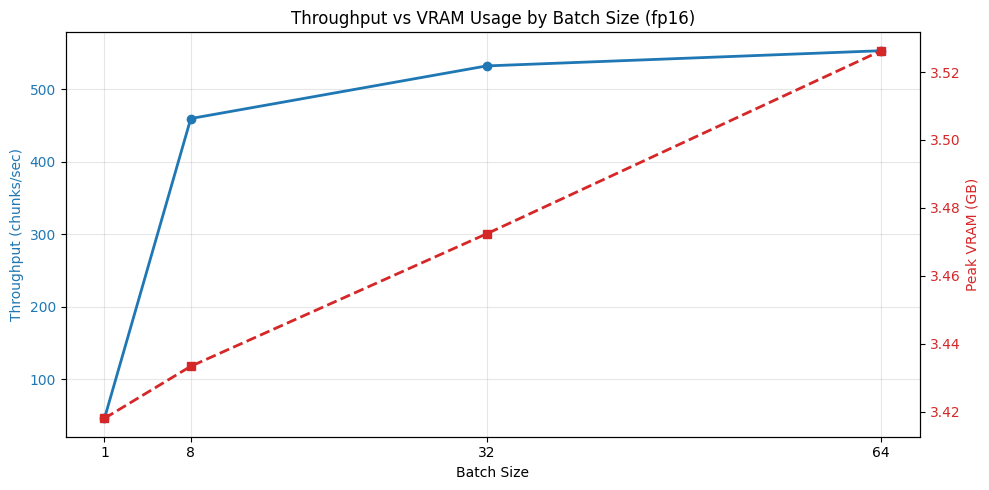

In [20]:
import matplotlib.pyplot as plt

# 이미 측정한 fp16 결과를 그래프에 사용한다.
fp16 = benchmark[benchmark["정밀도"] == "fp16"]
throughputs = fp16["청크/초"].tolist()
vrams = fp16["최대VRAM(GB)"].tolist()

# 그래프 시각화
fig, ax1 = plt.subplots(figsize=(10, 5))

# 좌측 Y축 (처리량)
color = 'tab:blue'
ax1.set_xlabel('Batch Size')
ax1.set_ylabel('Throughput (chunks/sec)', color=color)
ax1.plot(batch_sizes, throughputs, marker='o', color=color, linewidth=2, label='Throughput')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticks(batch_sizes)
ax1.grid(True, alpha=0.3)

# 우측 Y축 (VRAM 사용량)
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Peak VRAM (GB)', color=color)
ax2.plot(batch_sizes, vrams, marker='s', color=color, linestyle='--', linewidth=2, label='VRAM')
ax2.tick_params(axis='y', labelcolor=color)

# 제목 및 레이아웃
plt.title('Throughput vs VRAM Usage by Batch Size (fp16)')
fig.tight_layout()
plt.show()

In [21]:
import gc

del st_model
gc.collect()
torch.cuda.empty_cache()
print("측정용 모델 정리 완료. 검색용 bge_embeddings는 유지합니다.")

측정용 모델 정리 완료. 검색용 bge_embeddings는 유지합니다.


## Step 9. 로컬 LLM과 RAG 답변
예제의 `tokenizer`, `model`, `generate()`, `rag_answer()`를 사용한다.
이전에 CPU 배치로 느려졌던 문제를 막기 위해 Qwen을 GPU에 명시적으로 올린다.
답변 비교는 동일한 질문과 프롬프트로 수행한다. 검색 점수와 답변 정확도는 별도로 본다.

In [22]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
import torch

MODEL_NAME = "Qwen/Qwen2.5-7B-Instruct"

# 4bit 양자화 설정
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",                  # 4bit 표현 방식
    bnb_4bit_compute_dtype=torch.float16,       # 계산 정밀도. T4는 fp16 (bf16 미지원)
    bnb_4bit_use_double_quant=True,             # 양자화 상수를 한 번 더 양자화해 메모리 절약
)

if "model" not in globals():
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        quantization_config=bnb_config,
        device_map={"": 0},
        dtype=torch.float16,      # 양자화되지 않는 계층(임베딩 등)의 정밀도. T4는 bf16 미지원이라 fp16을 명시합니다
    )
model.eval()

print(f"모델 로드 완료. VRAM 사용량 : {torch.cuda.memory_allocated() / 1e9:.2f} GB")
print("Qwen 모델 배치:", model.hf_device_map)

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

...

model-00002-of-00004.safetensors:   0%|          | 0.00/3.86G [00:00<?, ?B/s]

model-00004-of-00004.safetensors:   0%|          | 0.00/3.56G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

모델 로드 완료. VRAM 사용량 : 7.84 GB
Qwen 모델 배치: {'': 0}


In [23]:
def generate(system_prompt: str, user_prompt: str, max_new_tokens: int = 192) -> str:
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt},
    ]
    inputs = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        return_tensors="pt",
        return_dict=True,         # input_ids 와 attention_mask 를 함께 받습니다
    ).to(model.device)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id,
        )

    return tokenizer.decode(output_ids[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)

In [24]:
SYSTEM_PROMPT = """당신은 따릉이 이용 안내 챗봇입니다.
아래 규칙을 지키세요.
1. 제공된 문서 내용에 근거해서만 답변합니다.
2. 답변 끝에 근거 항목을 표기합니다.
3. 문서에 없는 내용이면 "문서에서 확인되지 않습니다"라고 답합니다.
4. 답변은 반드시 한국어로 작성합니다. 절대 중국어를 사용하지 않습니다."""


def rag_answer(query: str, top_k: int = 3) -> str:
    contexts = retrieve(query, top_k)

    context_text = "\n\n".join(
        f"[{c['항목']}]\n{c['내용']}" for c in contexts
    )
    user_prompt = f"""다음은 따릉이 안내 문서에서 검색된 내용입니다.

{context_text}

질문 : {query}"""

    return generate(SYSTEM_PROMPT, user_prompt)

In [25]:
def hybrid_retrieve(query, top_k=3):
    # 앞서 만든 hybrid_rank로 상위 문서의 인덱스를 가져옵니다.
    top_indices = hybrid_rank(query, top_n=top_k)

    results = []
    for rank, idx in enumerate(top_indices):
        chunk = chunks[idx]
        results.append({
            "항목": chunk.metadata.get("항목", ""),
            "내용": chunk.page_content,
            "순위": rank + 1
        })
    return results

def hybrid_rag_answer(query: str, top_k: int = 3) -> str:
    contexts = hybrid_retrieve(query, top_k)

    context_text = "\n\n".join(
        f"[{c['항목']}]\n{c['내용']}" for c in contexts
    )
    user_prompt = f"다음은 따릉이 안내 문서에서 검색된 내용입니다.\n\n{context_text}\n\n질문 : {query}"

    return generate(SYSTEM_PROMPT, user_prompt)

def parent_rag_answer(query, child_top_k=6):
    parents = retrieve_parent(
        query,
        child_top_k=child_top_k,
        max_parents=3,
    )

    context_text = "\n\n".join(
        f"[{p['항목']}]\n{p['parent_text']}"
        for p in parents
    )

    user_prompt = (
        f"다음은 따릉이 안내 문서에서 검색된 내용입니다.\n\n"
        f"{context_text}\n\n질문 : {query}"
    )

    return generate(SYSTEM_PROMPT, user_prompt)

In [26]:
comparison_questions = [('횡단보도를 건널 때 자전거를 계속 타도 돼? 따로 자전거가 건너는 곳이 있으면?', '횡단보도에서는 끌고 가며, 자전거횡단도에서는 탑승한 채 건널 수 있다.'), ('7일권에서 1시간 이용권과 2시간 이용권 가격은 각각 얼마야?', '각각 3,000원과 4,000원이다.')]

for question, expected in comparison_questions:
    print(f"\n질문: {question}")
    print("[기준선]", rag_answer(question))
    print("[하이브리드]", hybrid_rag_answer(question))
    print("[부모–자식]", parent_rag_answer(question))
    print("[문서에서 확인할 내용]", expected)


질문: 횡단보도를 건널 때 자전거를 계속 타도 돼? 따로 자전거가 건너는 곳이 있으면?


The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


[기준선] 네, 자전거횡단도가 있으면 그곳에서는 자전거를 타고 건널 수 있습니다. 따라서 일반 횡단보도에서는 내려서 자전거를 끌고 가야 하지만, 자전거횡단도가 있는 경우에는 자전거를 타고 건널 수 있습니다.

근거: [횡단보도와 자전거횡단도]
[하이브리드] 네, 자전거 횡단도가 있으면 그곳에서는 자전거를 타고 건널 수 있습니다. 따라서 일반 횡단보도에서는 내려서 자전거를 끌고 가야 하지만, 자전거 횡단도가 마련되어 있으면 그곳에서는 자전거를 타고 건널 수 있습니다.

근거: [횡단보도와 자전거횡단도]
[부모–자식] 네, 자전거횡단도가 있으면 그곳에서는 자전거를 타고 건널 수 있습니다. 따라서 일반 횡단보도에서는 내려서 자전거를 끌고 가야 하지만, 자전거횡단도가 있는 경우에는 자전거를 타고 건널 수 있습니다.

근거: [횡단보도와 자전거횡단도]
[문서에서 확인할 내용] 횡단보도에서는 끌고 가며, 자전거횡단도에서는 탑승한 채 건널 수 있다.

질문: 7일권에서 1시간 이용권과 2시간 이용권 가격은 각각 얼마야?
[기준선] 7일권에서 1시간 단위 반복 이용권의 가격은 3,000원이고, 2시간 단위 반복 이용권의 가격은 4,000원입니다.  
근거: [7일권 요금]
[하이브리드] 7일권에서 1시간 단위 이용권의 가격은 3,000원이고, 2시간 단위 이용권의 가격은 4,000원입니다.  
근거: [7일권 요금]
[부모–자식] 7일권에서 1시간 단위 반복 이용권의 가격은 3,000원이고, 2시간 단위 반복 이용권의 가격은 4,000원입니다.  
근거: [7일권 요금]
[문서에서 확인할 내용] 각각 3,000원과 4,000원이다.


## Step 10. 오프라인 실행 확인
예제처럼 `HF_HUB_OFFLINE=1`을 설정하고 전체 RAG를 다시 호출한다.
이미 모델이 올라온 세션에서 새 질문의 임베딩·Qdrant 검색·답변 생성을 확인하는 범위이다.
환경변수 설정은 운영체제 전체의 네트워크 차단과 다르며, 모델을 처음 받는 단계는 포함하지 않는다.
아래 셀이 오류 없이 끝나고 답변을 출력하는지 확인한 뒤 그 출력을 제출한다.

In [27]:
import os

os.environ["HF_HUB_OFFLINE"] = "1"
os.environ["TRANSFORMERS_OFFLINE"] = "1"
print("HF_HUB_OFFLINE =", os.environ["HF_HUB_OFFLINE"])
print("TRANSFORMERS_OFFLINE =", os.environ["TRANSFORMERS_OFFLINE"])

print(rag_answer("365일권의 1시간 이용권과 2시간 이용권은 각각 얼마야?"))
print("오프라인 환경변수 설정 후 RAG 실행 완료")

HF_HUB_OFFLINE = 1
TRANSFORMERS_OFFLINE = 1
365일권의 1시간 단위 반복 이용권은 30,000원이고, 2시간 단위 반복 이용권은 40,000원입니다.  
근거: [365일권 요금]
오프라인 환경변수 설정 후 RAG 실행 완료


## Step 11. 실험 결과와 해석
표는 실제 실행값으로 만들어진다. 아래에서 기준선보다 좋아지지 않은 시도를 확인하고,
질문별 검색 결과와 문서를 근거로 해석을 작성한다.

In [28]:
display(summary)
no_gain = summary.iloc[1:][summary.iloc[1:]["기준선 대비 (%p)"] <= 0]

print("효과가 없었거나 오히려 나빠진 시도")
if no_gain.empty:
    print("아직 관찰되지 않았습니다. 이 과제 항목을 채우려면 추가 비교가 필요합니다.")
else:
    display(no_gain)
    # 개선이 없었던 첫 번째 방식의 질문별 결과를 보여준다.
    name = no_gain.iloc[0]["변경 내용"]
    display(details[details["방식"].isin(["기준선: 밀집 검색", name])])

report = "# 따릉이 로컬 RAG 실험 결과\n\n" + summary.to_markdown(index=False)
report += "\n\n## 효과가 없었거나 오히려 나빠진 시도\n\n"
report += no_gain.to_markdown(index=False) if not no_gain.empty else "아직 관찰되지 않음. 추가 실험 필요."
report += "\n\n## 왜 그런 결과가 나왔는지에 대한 해석\n\n"
report += "아래 노트북의 해석 칸에 실제 질문·검색 결과·원문을 대조하여 작성한다."
with open("bikeseoul_rag_results/experiment_report.md", "w", encoding="utf-8") as f:
    f.write(report)

,변경 내용,Hit@3 (%),기준선 대비 (%p),의미 Hit@3 (%),식별자 Hit@3 (%)
0,기준선: 밀집 검색,100.0,0.0,100.0,100.0
1,BM25 단독,90.0,-10.0,80.0,100.0
2,트랙2: RRF 1:1,100.0,0.0,100.0,100.0
3,트랙2: RRF 0.3:0.7,90.0,-10.0,80.0,100.0
4,트랙4: 자식3→부모3,100.0,0.0,100.0,100.0
5,트랙4: 자식6→부모3,100.0,0.0,100.0,100.0
6,트랙4: 자식12→부모3,100.0,0.0,100.0,100.0


효과가 없었거나 오히려 나빠진 시도


,변경 내용,Hit@3 (%),기준선 대비 (%p),의미 Hit@3 (%),식별자 Hit@3 (%)
1,BM25 단독,90.0,-10.0,80.0,100.0
2,트랙2: RRF 1:1,100.0,0.0,100.0,100.0
3,트랙2: RRF 0.3:0.7,90.0,-10.0,80.0,100.0
4,트랙4: 자식3→부모3,100.0,0.0,100.0,100.0
5,트랙4: 자식6→부모3,100.0,0.0,100.0,100.0
6,트랙4: 자식12→부모3,100.0,0.0,100.0,100.0


,방식,질문,정답,검색 결과,Hit@3,반환 부모 수
0,기준선: 밀집 검색,가입하지 않고도 이용권을 살 수 있어? 어떤 종류를 살 수 있어?,비회원 이용권,"[앱 설치와 이용권 구매, 비회원 이용권, QR 또는 자전거번호로 대여]",1,3
1,기준선: 밀집 검색,반납한 뒤 또 빌리고 싶은데 횟수 제한이 있어?,반납 후 재대여 조건,"[반납 후 재대여 조건, 대여시간 초과 요금, 180일권 요금]",1,3
2,기준선: 밀집 검색,빌린 자전거를 제시간에 돌려주지 못하면 추가로 얼마를 내야 해?,대여시간 초과 요금,"[대여시간 초과 요금, 반납 후 재대여 조건, 반납 절차와 완료 확인]",1,3
3,기준선: 밀집 검색,자전거를 세워 놓고 잠갔어. 바로 떠나도 될까?,반납 절차와 완료 확인,"[반납 절차와 완료 확인, 횡단보도와 자전거횡단도, 우산과 손에 든 물건]",1,3
4,기준선: 밀집 검색,횡단보도를 건널 때 자전거를 계속 타도 돼? 따로 자전거가 건너는 곳이 있으면?,횡단보도와 자전거횡단도,"[횡단보도와 자전거횡단도, 주행 금지 구역, 자전거도로와 우측통행]",1,3
5,기준선: 밀집 검색,초등학생 동생과 타려는데 이용 가능한 최소 나이는 몇 살이야?,이용 가능한 나이,"[이용 가능한 나이, QR 또는 자전거번호로 대여, 반납 후 재대여 조건]",1,3
6,기준선: 밀집 검색,자전거 전용 길이 없는 도로에서는 어디로 가야 해?,자전거도로와 우측통행,"[자전거도로와 우측통행, 주행 금지 구역, 안전거리와 주행 대열]",1,3
7,기준선: 밀집 검색,음악을 들으려고 이어폰을 끼고 달려도 돼?,주행 중 전자기기,"[주행 중 전자기기, 안전거리와 주행 대열, 보호장구와 복장]",1,3
8,기준선: 밀집 검색,비가 오면 한 손으로 우산을 잡고 타도 괜찮아?,우산과 손에 든 물건,"[우산과 손에 든 물건, 보호장구와 복장, 횡단보도와 자전거횡단도]",1,3
9,기준선: 밀집 검색,여럿이 함께 달릴 때 나란히 가도 돼?,안전거리와 주행 대열,"[안전거리와 주행 대열, 횡단보도와 자전거횡단도, 보호장구와 복장]",1,3


## 실험 결과와 해석

### 트랙 1. 배치 크기와 정밀도에 따른 처리량

fp32에서는 배치 1→32로 늘릴 때 처리량이 53→108청크/초로 증가했다. 배치 64에서는 105청크/초로 소폭 감소해, 배치를 계속 키운다고 처리량이 증가하지는 않았다.

fp16에서는 배치 1·8·32·64의 처리량이 각각 62·402·504·507청크/초였다. 배치 64 기준으로 fp32보다 약 4.8배 빨랐으며, 최대 GPU 메모리 사용량도 4.77GB에서 3.53GB로 감소했다.

다만 fp16의 배치 32→64에서는 처리량 증가가 약 0.6%에 그쳤다. 이번 측정에서는 배치 32도 최고 처리량에 가까웠다. 단회 측정이므로 작은 차이는 실행 변동을 포함할 수 있으며, 특정 배치가 항상 최적이라고 단정하지 않았다.

측정 데이터는 같은 문서를 반복한 1,000개 입력이다. 또한 GPU 메모리에는 검색용 BGE 모델도 포함되므로 측정용 모델만의 사용량으로 해석하지 않았다.

### 트랙 2·4. 검색 성능 비교

| 변경 내용 | Hit@3 | 기준선 대비 |
|---|---:|---:|
| 기준선: 밀집 검색 | 100% | — |
| BM25 단독 | 90% | -10%p |
| RRF 1:1 | 100% | 0%p |
| RRF 0.3:0.7 | 90% | -10%p |
| 자식 3개 → 부모 최대 3개 | 100% | 0%p |
| 자식 6개 → 부모 최대 3개 | 100% | 0%p |
| 자식 12개 → 부모 최대 3개 | 100% | 0%p |

기준선은 의미 질문 10개와 식별자 질문 10개를 모두 맞혔다. 따라서 이번 평가 세트에서는 Hit@3가 추가로 상승할 여지가 없었다.

### 효과가 없었거나 오히려 나빠진 시도

BM25 단독과 BM25의 비중을 높인 RRF 0.3:0.7은 기준선보다 10%p 낮았다. 두 방식 모두 식별자 질문은 100%였지만 의미 질문은 80%였다.

BM25 단독에서 실패한 질문은 다음 두 개였다.

- “빌린 자전거를 제시간에 돌려주지 못하면 추가로 얼마를 내야 해?”
  - 정답은 ‘대여시간 초과 요금’이다.
  - 기준선은 정답을 1위로 반환했지만, BM25는 횡단보도·우산·반납 절차 항목을 반환했다.
- “여럿이 함께 달릴 때 나란히 가도 돼?”
  - 정답은 ‘안전거리와 주행 대열’이다.
  - 기준선은 정답을 1위로 반환했지만, BM25는 음주 운전·주행 금지 구역·교통법규 항목을 반환했다.

RRF 1:1과 부모–자식 청킹은 기준선과 같은 100%를 유지했다. 자식 후보를 3개에서 12개까지 늘려도 Hit@3 개선은 관찰되지 않았다. 다만 같은 점수라고 해서 검색 순위나 반환 문서까지 모두 같다는 뜻은 아니다.

### 왜 이런 결과가 나왔는가

**문서의 성격:** 문서가 1,706자로 짧고, 부모 청크 22개가 이용권·절차·수칙별로 구분되어 있다. 기준선 청킹만으로도 정답 근거를 찾기 쉬웠던 것으로 해석된다. 부모가 이미 짧기 때문에 자식 43개로 더 나누는 효과도 제한적이었을 가능성이 있다.

**질문의 성격:** 의미 질문은 원문과 표현이 다르다. 예를 들어 “제시간에 돌려주지 못하면”은 문서의 “기본시간 초과”와 의미는 연결되지만 토큰이 일치하지 않는다. 현재 토큰화에서는 위 두 실패 질문과 각각의 정답 청크 사이에 일치하는 토큰이 없었다. 특히 “여럿이 함께…” 질문은 모든 문서의 BM25 점수가 0이어서, 반환 결과에 의미 있는 관련성 순위가 형성되지 않았다.

**검색 방식의 특성:** BGE는 표현이 달라도 의미 유사도를 활용할 수 있다. BM25는 365일권·ABC·QR처럼 질문과 문서에 동일하게 등장하는 식별자에 유리했다. BM25의 비중을 높였을 때 의미 질문 점수가 낮아진 것은, 어휘 일치가 약한 질문에서 BM25 순위의 영향이 커졌기 때문으로 해석할 수 있다.

### 로컬 Qwen 답변과 오프라인 실행

Qwen2.5-7B-Instruct를 4bit로 로드했으며, 모델 배치 출력은 `{'': 0}`으로 GPU 사용을 확인했다.

비교한 두 질문에서는 기준선·하이브리드·부모–자식 방식 모두 횡단보도와 자전거횡단도의 차이, 7일권의 1시간·2시간 요금을 올바르게 설명했다. 이 두 사례에서는 생성 답변의 뚜렷한 개선 차이가 관찰되지 않았다.

`HF_HUB_OFFLINE=1`, `TRANSFORMERS_OFFLINE=1` 설정 후에도 365일권 요금 질문에 정상적으로 답변했다. 이는 모델이 이미 로드된 세션에서의 실행 확인이며, 운영체제 전체의 네트워크 차단이나 최초 모델 로딩까지 검증한 것은 아니다.

In [29]:

import numpy as np
import pandas as pd
from rank_bm25 import BM25Okapi

# 트랙 2+4: 자식 문장에 대한 BM25 검색 준비
scenario_child_bm25 = BM25Okapi(
    [tokenize_ko(child["text"]) for child in children]
)

def scenario_hybrid_parent_retrieve(
    query, candidate_k=20, child_top_k=6, max_parents=3
):
    dense_hits = client.query_points(
        collection_name=CHILD_COLLECTION,
        query=bge_embeddings.embed_query(query),
        limit=candidate_k,
    ).points
    dense_ids = [int(hit.id) for hit in dense_hits]

    bm25_scores = scenario_child_bm25.get_scores(tokenize_ko(query))
    bm25_ids = [
        int(idx)
        for idx in np.argsort(bm25_scores)[::-1][:candidate_k]
    ]

    child_ids = rrf(
        [dense_ids, bm25_ids],
        k=60,
        top_n=child_top_k,
    )

    contexts = []
    seen = set()

    for child_id in child_ids:
        child = children[child_id]
        parent_id = child["parent_id"]

        if parent_id in seen:
            continue

        seen.add(parent_id)
        contexts.append({
            "항목": child["항목"],
            "내용": child["parent_text"],
        })

        if len(contexts) >= max_parents:
            break

    return contexts


def scenario_parent_retrieve(query):
    parents = retrieve_parent(
        query,
        child_top_k=6,
        max_parents=3,
    )
    return [
        {"항목": p["항목"], "내용": p["parent_text"]}
        for p in parents
    ]


scenario_methods = [
    ("기준선: 밀집 검색", lambda q: retrieve(q, top_k=3)),
    (
        "트랙 2: 하이브리드 RRF 1:1",
        lambda q: hybrid_retrieve(q, top_k=3),
    ),
    ("트랙 4: 부모–자식 검색", scenario_parent_retrieve),
    (
        "트랙 2+4: 하이브리드 부모–자식 검색",
        scenario_hybrid_parent_retrieve,
    ),
]

scenario_questions = [
    "1시간 이용권으로 오전에 40분 타고 반납했어. "
    "오후에 다시 빌려도 돼? 하루에 몇 번까지 탈 수 있어?",

    "365일권을 사려고 하는데, 1시간짜리와 2시간짜리는 "
    "각각 얼마야? 2시간짜리를 고르면 얼마 더 내?",

    "회원가입 없이 오늘만 두 시간 정도 타고 싶어. "
    "어떤 이용권을 살 수 있고 가격은 얼마야?",

    "자전거 타다가 횡단보도가 나왔어. "
    "옆에 자전거횡단도도 있으면 어디로 어떻게 건너야 해?",

    "자전거를 잠갔는데 반납 알림이 안 와. 그냥 가도 돼? "
    "앱에서 어떤 버튼을 눌러야 해결돼?",

    "지금 강남역 근처에서 바로 빌릴 수 있는 따릉이는 몇 대야? "
    "가장 가까운 대여소도 알려줘.",
]

scenario_results = []

for question_no, question in enumerate(scenario_questions, start=1):
    print("\n" + "=" * 80)
    print(f"질문 {question_no}/{len(scenario_questions)}")
    print(question, flush=True)

    for method_name, retrieve_fn in scenario_methods:
        print(f"\n[{method_name}]", flush=True)

        contexts = retrieve_fn(question)
        titles = [c["항목"] for c in contexts]
        print("검색 항목:", " / ".join(titles), flush=True)

        context_text = "\n\n".join(
            f"[{c['항목']}]\n{c['내용']}"
            for c in contexts
        )
        user_prompt = (
            "다음은 따릉이 안내 문서에서 검색된 내용입니다.\n\n"
            f"{context_text}\n\n질문 : {question}"
        )

        answer = generate(SYSTEM_PROMPT, user_prompt)
        print("답변:", answer, flush=True)

        scenario_results.append({
            "질문 번호": question_no,
            "질문": question,
            "방식": method_name,
            "검색 항목": " / ".join(titles),
            "전달 근거": context_text,
            "답변": answer,
        })

scenario_results_df = pd.DataFrame(scenario_results)
print(f"\n완료: 답변 {len(scenario_results_df)}개")


질문 1/6
1시간 이용권으로 오전에 40분 타고 반납했어. 오후에 다시 빌려도 돼? 하루에 몇 번까지 탈 수 있어?

[기준선: 밀집 검색]
검색 항목: 반납 후 재대여 조건 / 대여시간 초과 요금 / 30일권 요금
답변: 네, 오전에 40분 이용하고 정상적으로 반납하면 오후에 다시 대여할 수 있습니다. 이용권 기간 동안 횟수 제한 없이 다시 대여할 수 있으므로, 하루에 몇 번까지 탈 수 있는지에 대한 정보는 제공된 내용으로는 확인할 수 없습니다.

근거: [반납 후 재대여 조건]

[트랙 2: 하이브리드 RRF 1:1]
검색 항목: 반납 후 재대여 조건 / 대여시간 초과 요금 / 365일권 요금
답변: 네, 오전에 40분 이용하고 정상적으로 반납하면 오후에 다시 대여할 수 있습니다. 이용권 기간 동안 횟수 제한 없이 다시 대여할 수 있으므로, 하루에 몇 번까지 탈 수 있는지에 대한 정보는 제공된 내용으로는 확인할 수 없습니다.

근거: [반납 후 재대여 조건]

[트랙 4: 부모–자식 검색]
검색 항목: 반납 후 재대여 조건 / 대여시간 초과 요금 / 180일권 요금
답변: 네, 오전에 40분 이용하고 정상적으로 반납하면 오후에 다시 대여할 수 있습니다. 이용권 기간 동안 횟수 제한 없이 다시 대여할 수 있으므로, 하루에 몇 번까지 탈 수 있는지에 대한 정보는 제공된 내용으로는 확인할 수 없습니다.

근거: [반납 후 재대여 조건]

[트랙 2+4: 하이브리드 부모–자식 검색]
검색 항목: 반납 후 재대여 조건 / 대여시간 초과 요금 / 365일권 요금
답변: 네, 오전에 40분 이용하고 정상적으로 반납하면 오후에 다시 대여할 수 있습니다. 이용권 기간 동안 횟수 제한 없이 다시 대여할 수 있으므로, 하루에 몇 번까지 탈 수 있는지에 대한 정보는 제공된 내용으로는 확인할 수 없습니다.

근거: [반납 후 재대여 조건]

질문 2/6
365일권을 사려고 하는데, 1시간짜리와 2시간짜리는 각각 얼마야? 2시간짜리를 고르면 얼마 더 내?

[기준선: 밀집 검색